<a href="https://www.kaggle.com/code/yashikagoyal2105/early-pcos-risk-detection?scriptVersionId=324807299" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [9]:
# scope = ["https://spreadsheets.google.com/feeds",
#          "https://www.googleapis.com/auth/drive"]

# creds = ServiceAccountCredentials.from_json_keyfile_name(
#     "/kaggle/input/datasets/yashikagoyal2105/multi-risk-pcos-prediction/regal-autonomy-395418-08747587d04a.json", scope
# )
# client = gspread.authorize(creds)


In [16]:
# ==============================
# 1. Imports
# ==============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.impute import SimpleImputer

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from imblearn.over_sampling import BorderlineSMOTE
from imblearn.combine import SMOTEENN

import shap
import optuna
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [17]:
# ==============================
# 2. Load Data
# ==============================
physical_df = pd.read_csv("/kaggle/input/datasets/yashikagoyal2105/pcos-data/physical_data.csv")
clinical_df = pd.read_csv("/kaggle/input/datasets/yashikagoyal2105/pcos-data/clinical_data.csv")
clinical_marriage_df = pd.read_csv("/kaggle/input/datasets/yashikagoyal2105/pcos-data/clinical_marriage_data.csv")

# Merge for combined dataset
combined_df = physical_df.merge(clinical_marriage_df, on="Patient File No.", how="outer")

# Fix duplicate target columns
if "PCOS (Y/N)_x" in combined_df.columns and "PCOS (Y/N)_y" in combined_df.columns:
    combined_df["PCOS (Y/N)"] = combined_df["PCOS (Y/N)_x"].fillna(combined_df["PCOS (Y/N)_y"])
    combined_df = combined_df.drop(["PCOS (Y/N)_x","PCOS (Y/N)_y"], axis=1)

In [18]:
# ==============================
# 3. Feature Engineering
# ==============================
def add_features(df):
    if "BMI" in df.columns:
        df["BMI_Category"] = pd.cut(df["BMI"], bins=[0,18.5,25,30,100],
                                    labels=["Underweight","Normal","Overweight","Obese"])
    if "Age (yrs)" in df.columns:
        df["Age_Group"] = pd.cut(df["Age (yrs)"], bins=[0,20,30,40,50,100],
                                 labels=["Teen","20s","30s","40s","50+"])
    if "Waist(inch)" in df.columns and "Height(Cm)" in df.columns:
        df["Waist_Height_Ratio"] = df["Waist(inch)"] / df["Height(Cm)"]
    if "Weight (Kg)" in df.columns and "Height(Cm)" in df.columns:
        df["Weight_Height_Ratio"] = df["Weight (Kg)"] / df["Height(Cm)"]
    for col in ["BMI","Waist(inch)","Weight (Kg)"]:
        if col in df.columns:
            df[col+"_log"] = np.log1p(df[col])
    return df

physical_df = add_features(physical_df)
clinical_df = add_features(clinical_df)
clinical_marriage_df = add_features(clinical_marriage_df)
combined_df = add_features(combined_df)

In [19]:
# ==============================
# 4. Preprocessing
# ==============================
def preprocess_dataset(df, target="PCOS (Y/N)", poly=False, balance_method="smote"):
    df = df.drop_duplicates()
    X = df.drop(target, axis=1)
    y = df[target]

    # Encode categorical
    X = pd.get_dummies(X, drop_first=True)

    # Impute missing values before scaling/poly
    imputer = SimpleImputer(strategy="median")
    X = imputer.fit_transform(X)

    # Scale
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # Polynomial features (optional)
    if poly:
        poly_feat = PolynomialFeatures(degree=2, include_bias=False)
        X = poly_feat.fit_transform(X)

    # Balance dataset
    if balance_method=="borderline":
        sampler = BorderlineSMOTE(random_state=RANDOM_STATE)
    elif balance_method=="smoteenn":
        sampler = SMOTEENN(random_state=RANDOM_STATE)
    else:
        sampler = BorderlineSMOTE(random_state=RANDOM_STATE)  # default
    X, y = sampler.fit_resample(X, y)

    return X, y

In [20]:
# ==============================
# 5. Optuna Optimization for XGBoost
# ==============================
def optimize_xgb(X_train, y_train, X_test, y_test):
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "random_state": RANDOM_STATE,
            "eval_metric": "logloss",
            "use_label_encoder": False
        }
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:,1]
        return roc_auc_score(y_test, y_prob)
    
    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=20)
    return study.best_params

In [21]:
def run_all_models(X, y, label):
    results = []
    models = {}
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                        stratify=y, random_state=RANDOM_STATE)

    # --- Optuna XGBoost ---
    best_params = optimize_xgb(X_train, y_train, X_test, y_test)
    xgb = XGBClassifier(**best_params)
    xgb.fit(X_train, y_train)
    models["XGBoost (Optuna)"] = xgb
    y_pred = xgb.predict(X_test)
    y_prob = xgb.predict_proba(X_test)[:,1]
    results.append({"Model":"XGBoost (Optuna)","Dataset":label,
                    "Accuracy":accuracy_score(y_test,y_pred),
                    "Precision":precision_score(y_test,y_pred),
                    "Recall":recall_score(y_test,y_pred),
                    "F1":f1_score(y_test,y_pred),
                    "ROC-AUC":roc_auc_score(y_test,y_prob)})

    # --- LightGBM ---
    lgbm = LGBMClassifier(random_state=RANDOM_STATE)
    lgbm.fit(X_train, y_train)
    models["LightGBM"] = lgbm
    y_pred = lgbm.predict(X_test)
    y_prob = lgbm.predict_proba(X_test)[:,1]
    results.append({"Model":"LightGBM","Dataset":label,
                    "Accuracy":accuracy_score(y_test,y_pred),
                    "Precision":precision_score(y_test,y_pred),
                    "Recall":recall_score(y_test,y_pred),
                    "F1":f1_score(y_test,y_pred),
                    "ROC-AUC":roc_auc_score(y_test,y_prob)})

    # --- CatBoost ---
    cat = CatBoostClassifier(verbose=0, random_state=RANDOM_STATE)
    cat.fit(X_train, y_train)
    models["CatBoost"] = cat
    y_pred = cat.predict(X_test)
    y_prob = cat.predict_proba(X_test)[:,1]
    results.append({"Model":"CatBoost","Dataset":label,
                    "Accuracy":accuracy_score(y_test,y_pred),
                    "Precision":precision_score(y_test,y_pred),
                    "Recall":recall_score(y_test,y_pred),
                    "F1":f1_score(y_test,y_pred),
                    "ROC-AUC":roc_auc_score(y_test,y_prob)})

    # --- Stacked Ensemble ---
    stack = StackingClassifier(
        estimators=[("xgb",xgb),("lgbm",lgbm),("cat",cat)],
        final_estimator=LogisticRegression())
    stack.fit(X_train, y_train)
    models["Stacked Ensemble"] = stack
    y_pred = stack.predict(X_test)
    y_prob = stack.predict_proba(X_test)[:,1]
    results.append({"Model":"Stacked Ensemble","Dataset":label,
                    "Accuracy":accuracy_score(y_test,y_pred),
                    "Precision":precision_score(y_test,y_pred),
                    "Recall":recall_score(y_test,y_pred),
                    "F1":f1_score(y_test,y_pred),
                    "ROC-AUC":roc_auc_score(y_test,y_prob)})

    return pd.DataFrame(results), models, X_test, y_test


In [26]:
# Preprocess each dataset
X_phys, y_phys = preprocess_dataset(physical_df, poly=True)
X_clin, y_clin = preprocess_dataset(clinical_df)
X_clin_m, y_clin_m = preprocess_dataset(clinical_marriage_df)
X_comb, y_comb = preprocess_dataset(combined_df)


In [27]:
results_phys, models_phys, X_phys_test, y_phys_test = run_all_models(X_phys, y_phys, "Physical-only")
results_clin, models_clin, X_clin_test, y_clin_test = run_all_models(X_clin, y_clin, "Clinical-only (no marriage)")
results_clin_m, models_clin_m, X_clin_m_test, y_clin_m_test = run_all_models(X_clin_m, y_clin_m, "Clinical-only (with marriage)")
results_comb, models_comb, X_comb_test, y_comb_test = run_all_models(X_comb, y_comb, "Combined dataset")

final_results = pd.concat([results_phys, results_clin, results_clin_m, results_comb], ignore_index=True)


[I 2026-06-05 16:14:08,596] A new study created in memory with name: no-name-7b40d202-63c3-4cff-a068-00a06358a064
[I 2026-06-05 16:14:13,538] Trial 0 finished with value: 0.9688496903734283 and parameters: {'n_estimators': 113, 'max_depth': 9, 'learning_rate': 0.012619864093458031, 'subsample': 0.699499368804395, 'colsample_bytree': 0.9441275359980333}. Best is trial 0 with value: 0.9688496903734283.
[I 2026-06-05 16:14:17,227] Trial 1 finished with value: 0.9786076186901858 and parameters: {'n_estimators': 187, 'max_depth': 6, 'learning_rate': 0.06402973677143647, 'subsample': 0.8517129726991184, 'colsample_bytree': 0.7867691321330459}. Best is trial 1 with value: 0.9786076186901858.
[I 2026-06-05 16:14:21,050] Trial 2 finished with value: 0.9754175267404765 and parameters: {'n_estimators': 435, 'max_depth': 10, 'learning_rate': 0.13997978910977357, 'subsample': 0.711104367824759, 'colsample_bytree': 0.9703813893793057}. Best is trial 1 with value: 0.9786076186901858.
[I 2026-06-05 16

[LightGBM] [Info] Number of positive: 291, number of negative: 291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 55536
[LightGBM] [Info] Number of data points in the train set: 582, number of used features: 495
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

[I 2026-06-05 16:21:32,157] A new study created in memory with name: no-name-1829263a-af9f-4959-a723-9eab726b35f3
[I 2026-06-05 16:21:32,644] Trial 0 finished with value: 0.9656595984237193 and parameters: {'n_estimators': 198, 'max_depth': 5, 'learning_rate': 0.025005836140891684, 'subsample': 0.7060509139024889, 'colsample_bytree': 0.6930448308253188}. Best is trial 0 with value: 0.9656595984237193.
[I 2026-06-05 16:21:33,158] Trial 1 finished with value: 0.9602176768624506 and parameters: {'n_estimators': 283, 'max_depth': 9, 'learning_rate': 0.25150686873880834, 'subsample': 0.9950513624176993, 'colsample_bytree': 0.8680968110985032}. Best is trial 0 with value: 0.9656595984237193.
[I 2026-06-05 16:21:33,748] Trial 2 finished with value: 0.9654719459560894 and parameters: {'n_estimators': 277, 'max_depth': 4, 'learning_rate': 0.04918518089191072, 'subsample': 0.6567777519528967, 'colsample_bytree': 0.9004926585145671}. Best is trial 0 with value: 0.9656595984237193.
[I 2026-06-05 1

[LightGBM] [Info] Number of positive: 291, number of negative: 291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000231 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2599
[LightGBM] [Info] Number of data points in the train set: 582, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[I 2026-06-05 16:22:24,027] A new study created in memory with name: no-name-8f77cc19-9c13-4363-9a5c-8c5f957e8143
[I 2026-06-05 16:22:24,539] Trial 0 finished with value: 0.9680990805029086 and parameters: {'n_estimators': 192, 'max_depth': 9, 'learning_rate': 0.14523055346057415, 'subsample': 0.7675173848461927, 'colsample_bytree': 0.8882973751046154}. Best is trial 0 with value: 0.9680990805029086.
[I 2026-06-05 16:22:25,339] Trial 1 finished with value: 0.9652842934884593 and parameters: {'n_estimators': 387, 'max_depth': 9, 'learning_rate': 0.11560176203521554, 'subsample': 0.9724601222703533, 'colsample_bytree': 0.7429853272425233}. Best is trial 0 with value: 0.9680990805029086.
[I 2026-06-05 16:22:25,711] Trial 2 finished with value: 0.9624695064740102 and parameters: {'n_estimators': 150, 'max_depth': 8, 'learning_rate': 0.16877222450441734, 'subsample': 0.7986326167327557, 'colsample_bytree': 0.7368374737650856}. Best is trial 0 with value: 0.9680990805029086.
[I 2026-06-05 16

[LightGBM] [Info] Number of positive: 291, number of negative: 291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000391 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2737
[LightGBM] [Info] Number of data points in the train set: 582, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

[I 2026-06-05 16:23:16,824] A new study created in memory with name: no-name-2bb0cbda-0f42-49e1-9839-9d038e48287e
[I 2026-06-05 16:23:17,374] Trial 0 finished with value: 0.9947457309063614 and parameters: {'n_estimators': 318, 'max_depth': 7, 'learning_rate': 0.22185072963468488, 'subsample': 0.7534459127133538, 'colsample_bytree': 0.6465528378890645}. Best is trial 0 with value: 0.9947457309063614.
[I 2026-06-05 16:23:17,999] Trial 1 finished with value: 0.9930568586976918 and parameters: {'n_estimators': 284, 'max_depth': 10, 'learning_rate': 0.14029513862768792, 'subsample': 0.8288945913473998, 'colsample_bytree': 0.8079501934723579}. Best is trial 0 with value: 0.9947457309063614.
[I 2026-06-05 16:23:18,326] Trial 2 finished with value: 0.9951210358416213 and parameters: {'n_estimators': 120, 'max_depth': 6, 'learning_rate': 0.1718867285373178, 'subsample': 0.9716260544851288, 'colsample_bytree': 0.659447466648156}. Best is trial 2 with value: 0.9951210358416213.
[I 2026-06-05 16:

[LightGBM] [Info] Number of positive: 291, number of negative: 291
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000545 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4684
[LightGBM] [Info] Number of data points in the train set: 582, number of used features: 58
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

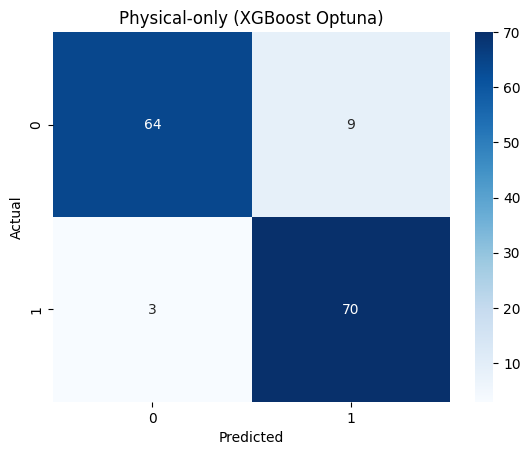

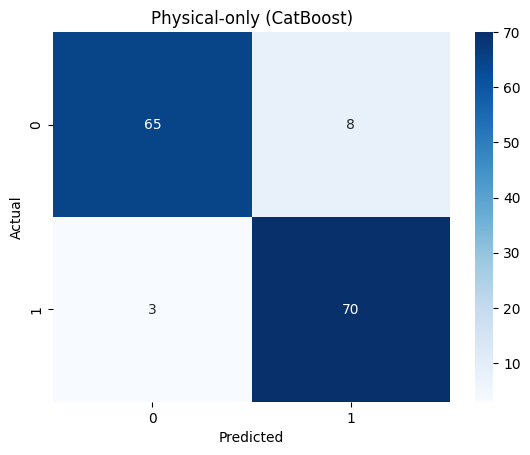

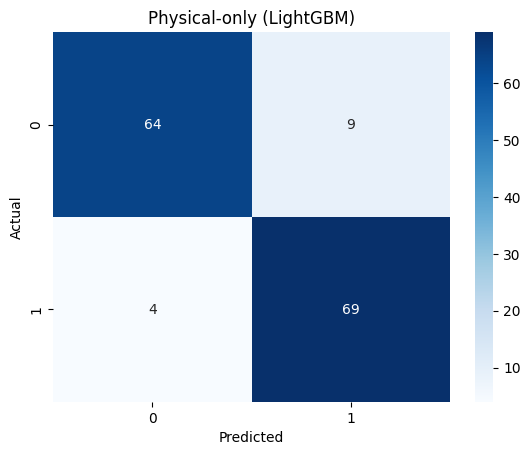

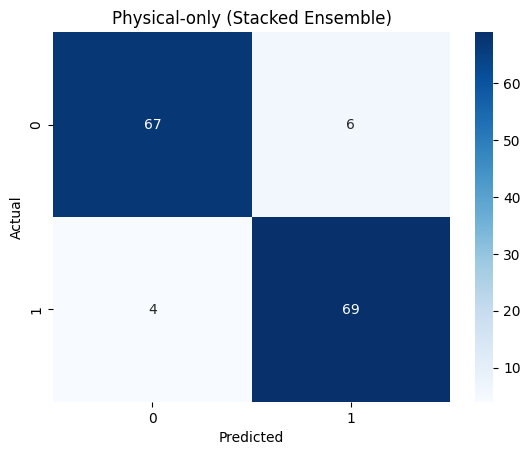

In [29]:
# Confusion matrix plotting function
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Now you can call it safely
plot_confusion(y_phys_test, models_phys["XGBoost (Optuna)"].predict(X_phys_test), "Physical-only (XGBoost Optuna)")
plot_confusion(y_phys_test, models_phys["CatBoost"].predict(X_phys_test), "Physical-only (CatBoost)")
plot_confusion(y_phys_test, models_phys["LightGBM"].predict(X_phys_test), "Physical-only (LightGBM)")
plot_confusion(y_phys_test, models_phys["Stacked Ensemble"].predict(X_phys_test), "Physical-only (Stacked Ensemble)")


In [30]:
def plot_roc_curves(models_dict, X_test, y_test, dataset_label):
    plt.figure(figsize=(8,6))
    for name, model in models_dict.items():
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    plt.plot([0,1],[0,1],"k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves - {dataset_label}")
    plt.legend()
    plt.show()


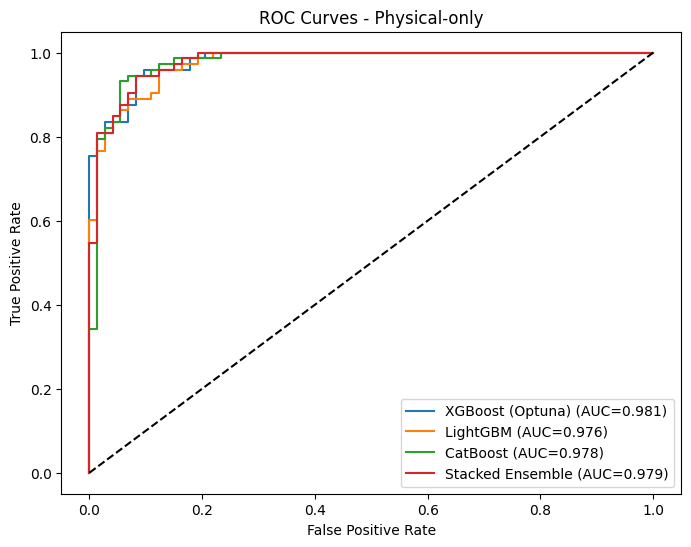

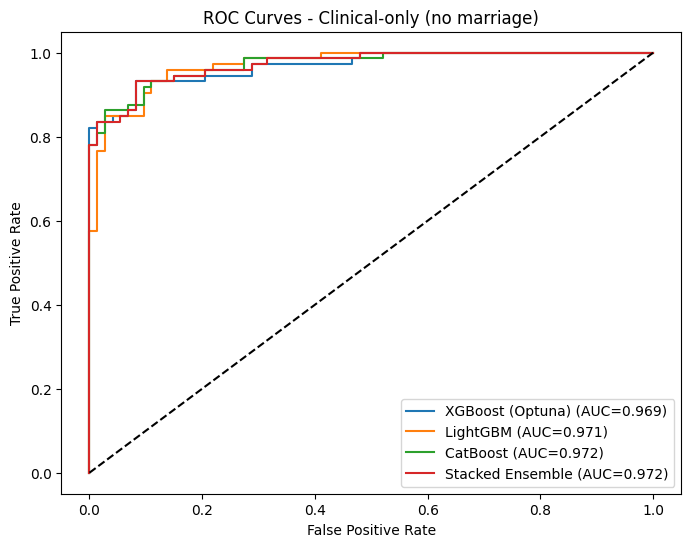

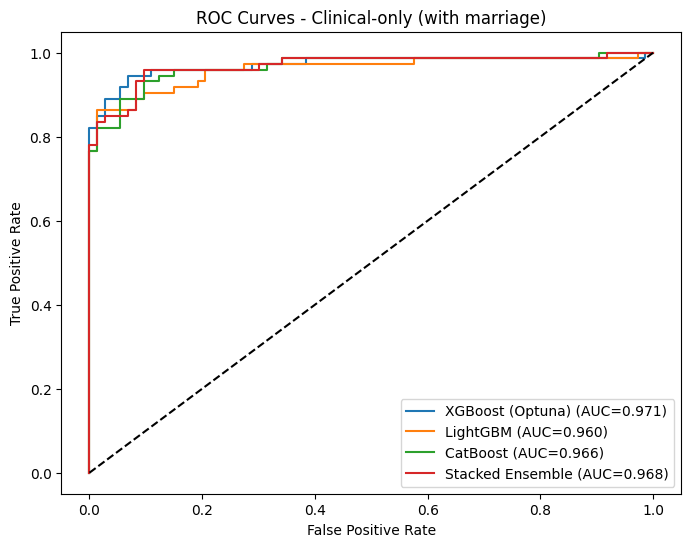

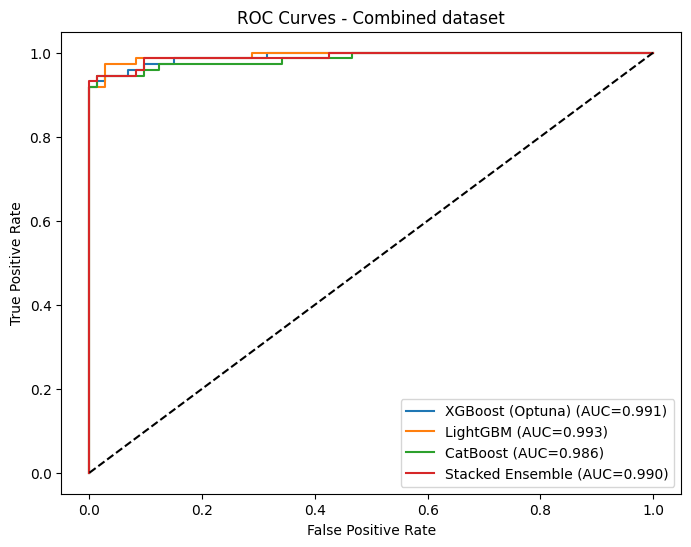

In [31]:
plot_roc_curves(models_phys, X_phys_test, y_phys_test, "Physical-only")
plot_roc_curves(models_clin, X_clin_test, y_clin_test, "Clinical-only (no marriage)")
plot_roc_curves(models_clin_m, X_clin_m_test, y_clin_m_test, "Clinical-only (with marriage)")
plot_roc_curves(models_comb, X_comb_test, y_comb_test, "Combined dataset")


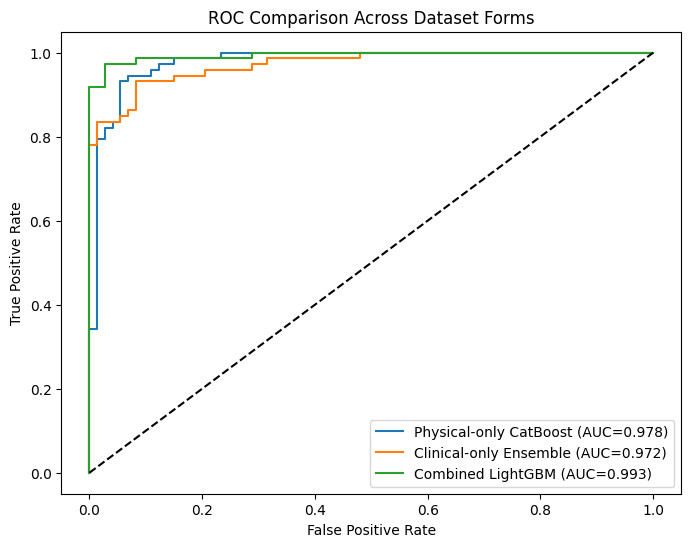

In [32]:
plt.figure(figsize=(8,6))

# Physical-only best model (CatBoost)
y_prob_phys = models_phys["CatBoost"].predict_proba(X_phys_test)[:,1]
fpr, tpr, _ = roc_curve(y_phys_test, y_prob_phys)
plt.plot(fpr, tpr, label=f"Physical-only CatBoost (AUC={roc_auc_score(y_phys_test,y_prob_phys):.3f})")

# Clinical-only best model (Stacked Ensemble)
y_prob_clin = models_clin["Stacked Ensemble"].predict_proba(X_clin_test)[:,1]
fpr, tpr, _ = roc_curve(y_clin_test, y_prob_clin)
plt.plot(fpr, tpr, label=f"Clinical-only Ensemble (AUC={roc_auc_score(y_clin_test,y_prob_clin):.3f})")

# Combined best model (LightGBM)
y_prob_comb = models_comb["LightGBM"].predict_proba(X_comb_test)[:,1]
fpr, tpr, _ = roc_curve(y_comb_test, y_prob_comb)
plt.plot(fpr, tpr, label=f"Combined LightGBM (AUC={roc_auc_score(y_comb_test,y_prob_comb):.3f})")

plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Comparison Across Dataset Forms")
plt.legend()
plt.show()


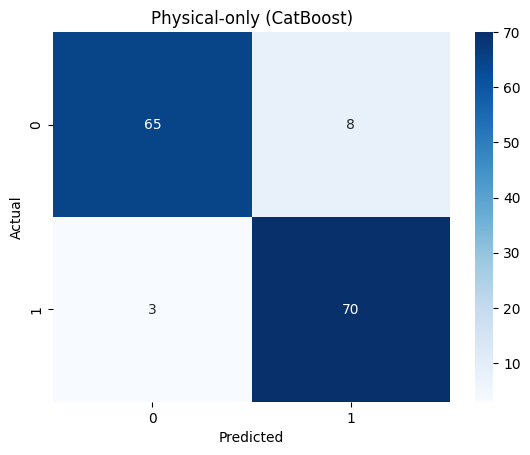

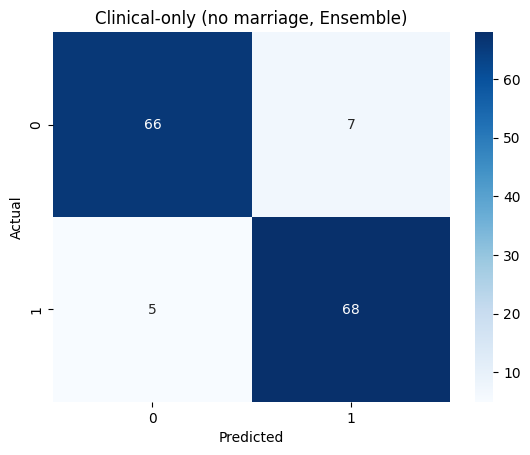

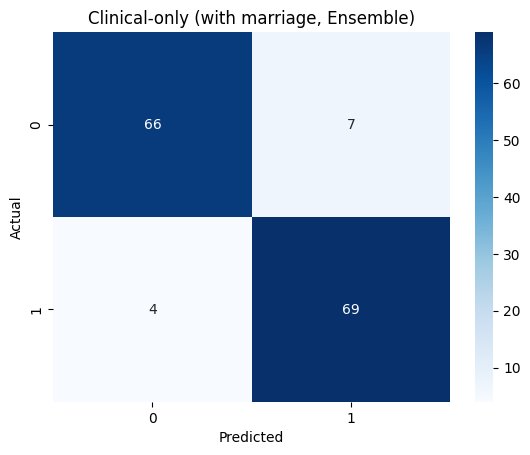

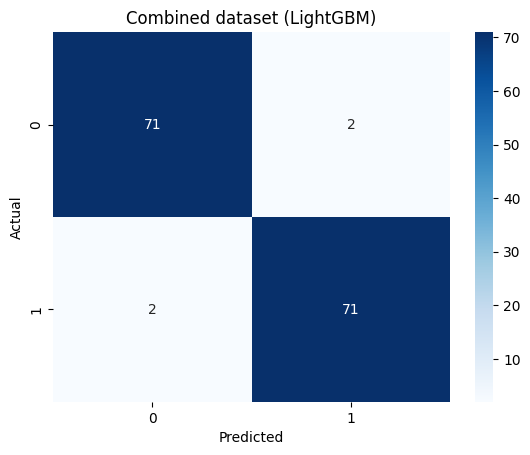

In [33]:
# Confusion matrix plotting function
def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Physical-only best model (CatBoost)
plot_confusion(y_phys_test, models_phys["CatBoost"].predict(X_phys_test), "Physical-only (CatBoost)")

# Clinical-only (no marriage) best model (Stacked Ensemble)
plot_confusion(y_clin_test, models_clin["Stacked Ensemble"].predict(X_clin_test), "Clinical-only (no marriage, Ensemble)")

# Clinical-only (with marriage) best model (Stacked Ensemble)
plot_confusion(y_clin_m_test, models_clin_m["Stacked Ensemble"].predict(X_clin_m_test), "Clinical-only (with marriage, Ensemble)")

# Combined dataset best model (LightGBM)
plot_confusion(y_comb_test, models_comb["LightGBM"].predict(X_comb_test), "Combined dataset (LightGBM)")


In [34]:
# Styled table for all models across all datasets
styled_all = final_results.style\
    .background_gradient(cmap="Blues")\
    .format("{:.3f}", subset=["Accuracy","Precision","Recall","F1","ROC-AUC"])\
    .set_caption("Performance of All Models Across Dataset Forms")

styled_all



,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost (Optuna),Physical-only,0.918,0.886,0.959,0.921,0.981
1,LightGBM,Physical-only,0.911,0.885,0.945,0.914,0.976
2,CatBoost,Physical-only,0.925,0.897,0.959,0.927,0.978
3,Stacked Ensemble,Physical-only,0.932,0.920,0.945,0.932,0.979
4,XGBoost (Optuna),Clinical-only (no marriage),0.918,0.918,0.918,0.918,0.969
5,LightGBM,Clinical-only (no marriage),0.911,0.895,0.932,0.913,0.971
6,CatBoost,Clinical-only (no marriage),0.911,0.895,0.932,0.913,0.972
7,Stacked Ensemble,Clinical-only (no marriage),0.918,0.907,0.932,0.919,0.972
8,XGBoost (Optuna),Clinical-only (with marriage),0.918,0.896,0.945,0.920,0.971
9,LightGBM,Clinical-only (with marriage),0.897,0.892,0.904,0.898,0.960


In [35]:
# Find best model per dataset by highest ROC-AUC
best_per_dataset = final_results.loc[
    final_results.groupby("Dataset")["ROC-AUC"].idxmax()
]

# Styled summary table
styled_summary = best_per_dataset.style\
    .background_gradient(cmap="Greens")\
    .format("{:.3f}", subset=["Accuracy","Precision","Recall","F1","ROC-AUC"])\
    .set_caption("Best Model per Dataset (Auto-selected by ROC-AUC)")

styled_summary


,Model,Dataset,Accuracy,Precision,Recall,F1,ROC-AUC
7,Stacked Ensemble,Clinical-only (no marriage),0.918,0.907,0.932,0.919,0.972
8,XGBoost (Optuna),Clinical-only (with marriage),0.918,0.896,0.945,0.920,0.971
13,LightGBM,Combined dataset,0.973,0.973,0.973,0.973,0.993
0,XGBoost (Optuna),Physical-only,0.918,0.886,0.959,0.921,0.981


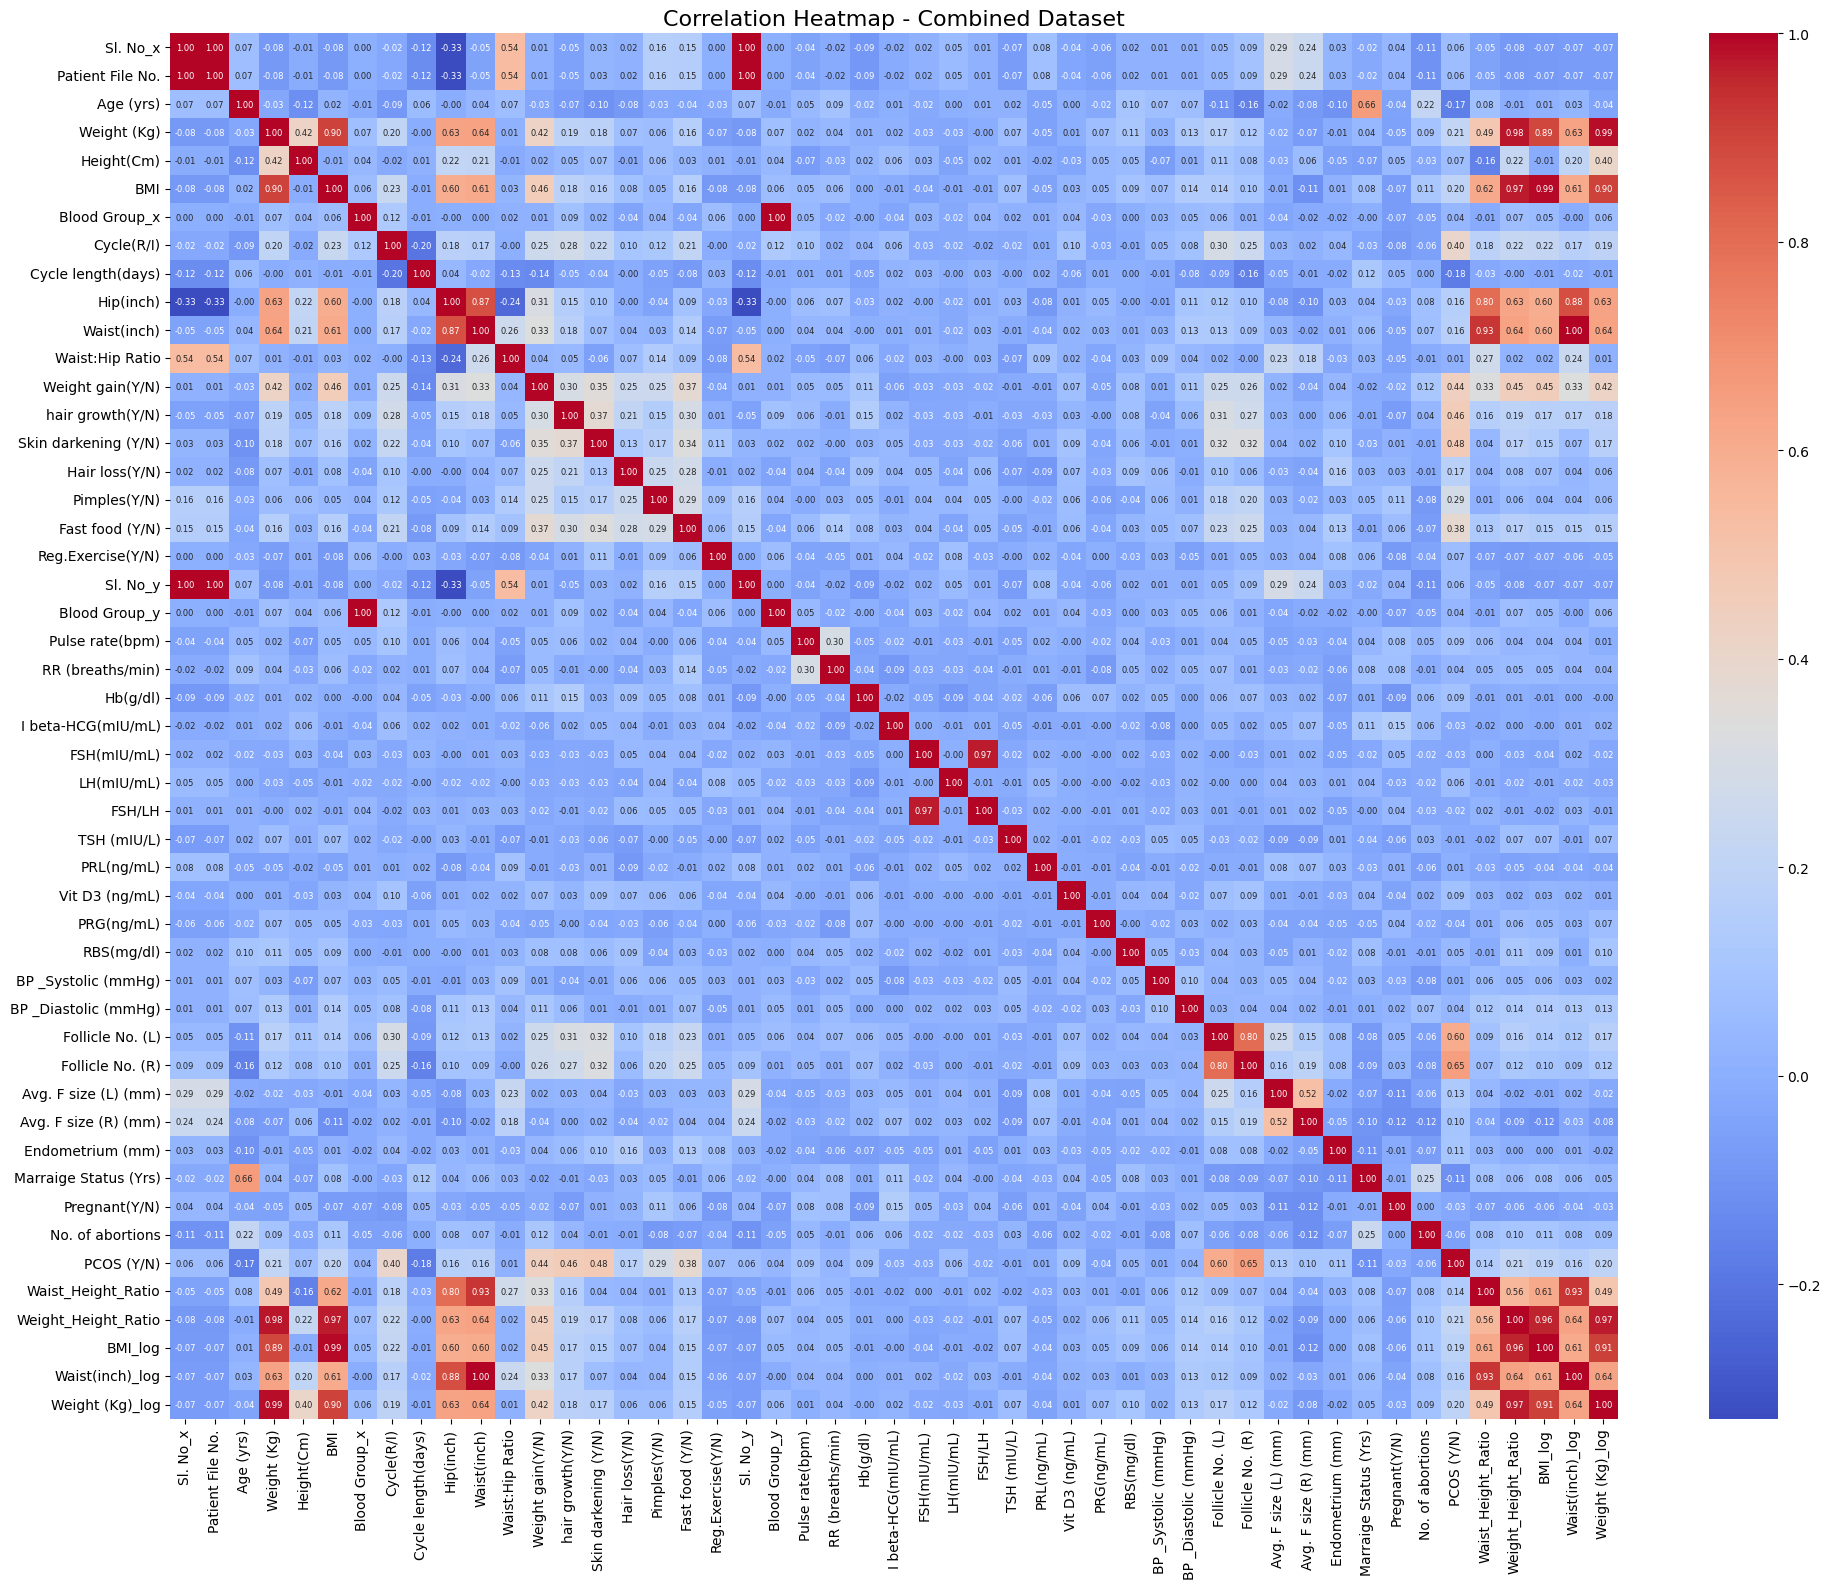

In [39]:
# Select only numeric columns from combined_df
numeric_df = combined_df.select_dtypes(include=[np.number])

# Optional: clean malformed numeric values (like "1.99.")
numeric_df = numeric_df.apply(pd.to_numeric, errors="coerce")


plt.figure(figsize=(20, 16))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size": 6}  # smaller text
)

plt.title("Correlation Heatmap - Combined Dataset", fontsize=16)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

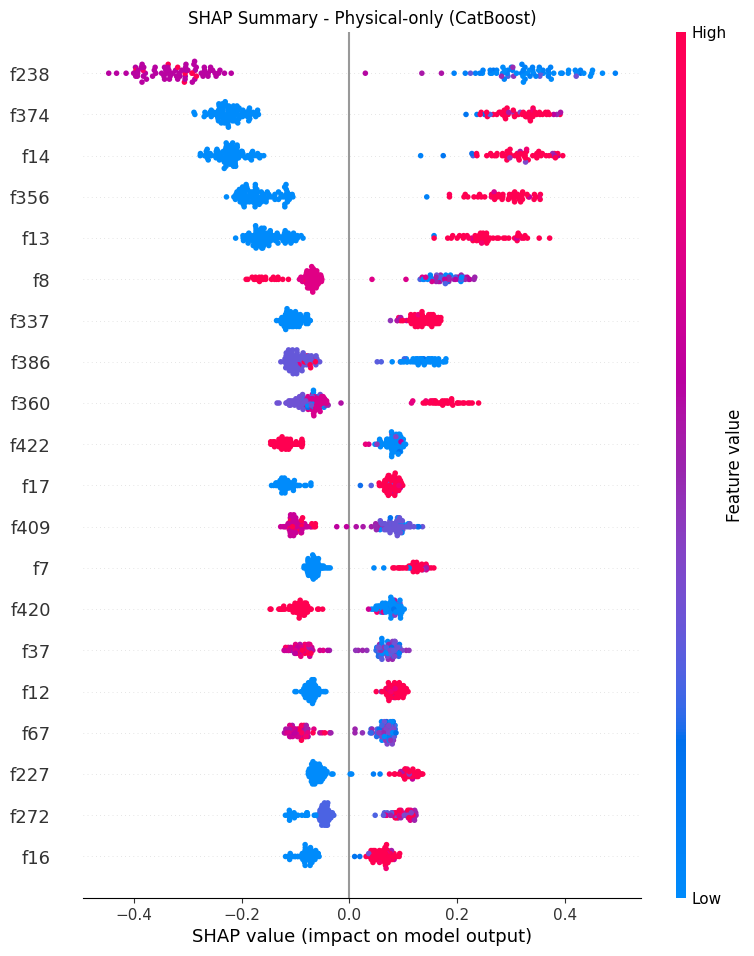

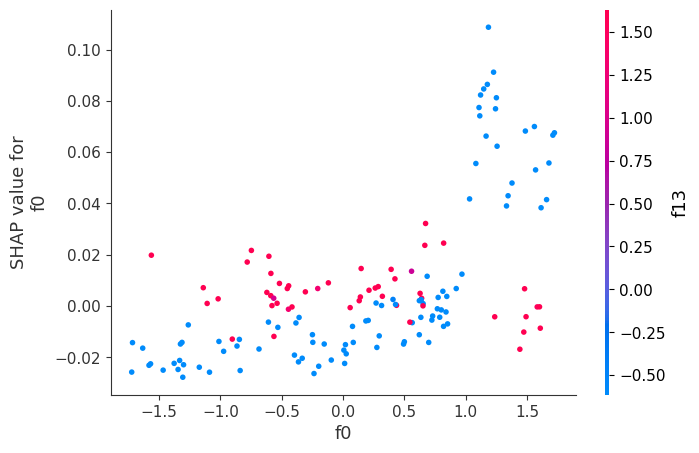

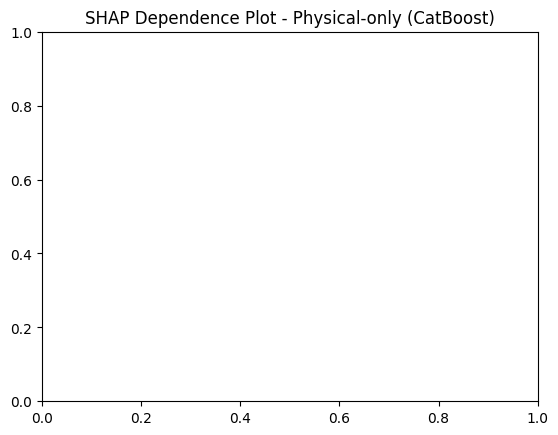

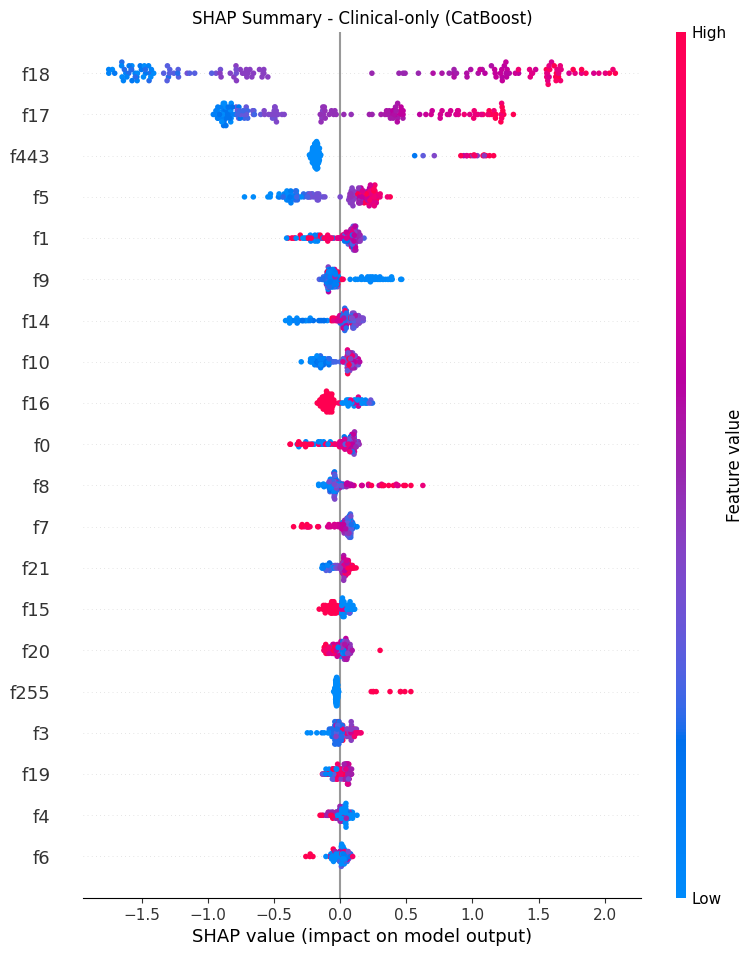

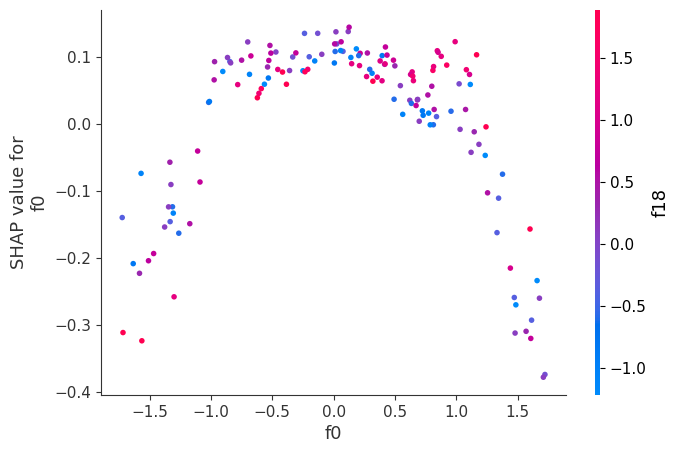

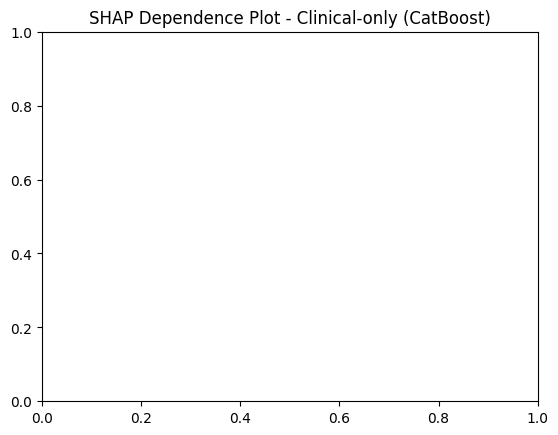

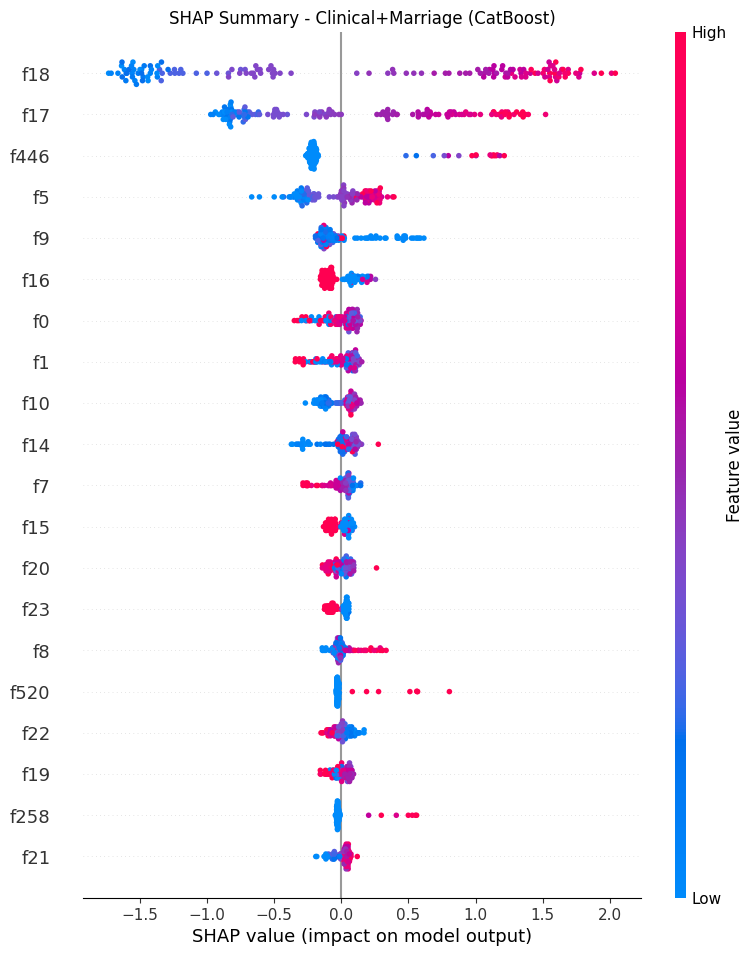

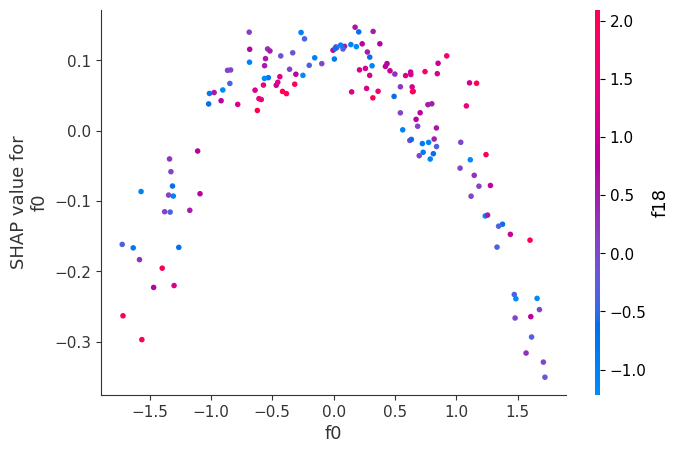

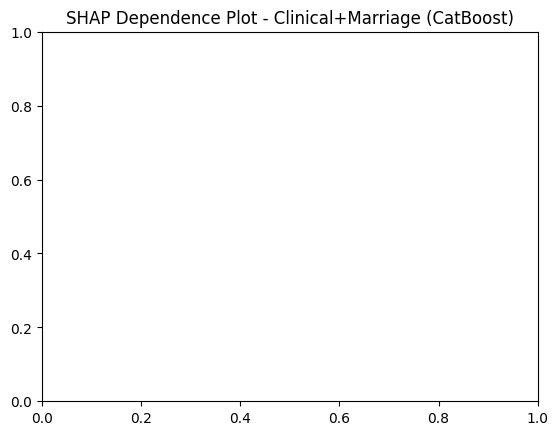

In [40]:
# Example: preserve feature names after preprocessing
X_clin, y_clin = preprocess_dataset(clinical_df)
feature_names_clin = [f"f{i}" for i in range(X_clin.shape[1])]

def shap_explain(model, X, feature_names, label):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    
    # Global summary plot
    shap.summary_plot(shap_values, X, feature_names=feature_names, show=False)
    plt.title(f"SHAP Summary - {label}")
    plt.show()
    
    # Dependence plot for a meaningful feature (e.g., BMI if available)
    shap.dependence_plot(0, shap_values, X, feature_names=feature_names)
    plt.title(f"SHAP Dependence Plot - {label}")
    plt.show()

# Run for each dataset
shap_explain(models_phys["CatBoost"], X_phys_test, [f"f{i}" for i in range(X_phys_test.shape[1])], "Physical-only (CatBoost)")
shap_explain(models_clin["CatBoost"], X_clin_test, [f"f{i}" for i in range(X_clin_test.shape[1])], "Clinical-only (CatBoost)")
shap_explain(models_clin_m["CatBoost"], X_clin_m_test, [f"f{i}" for i in range(X_clin_m_test.shape[1])], "Clinical+Marriage (CatBoost)")


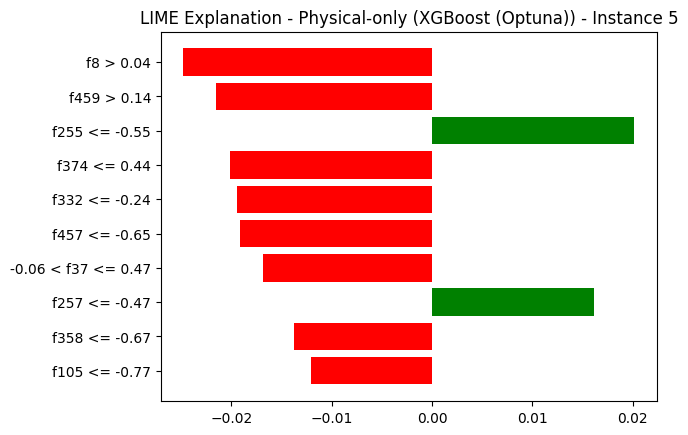

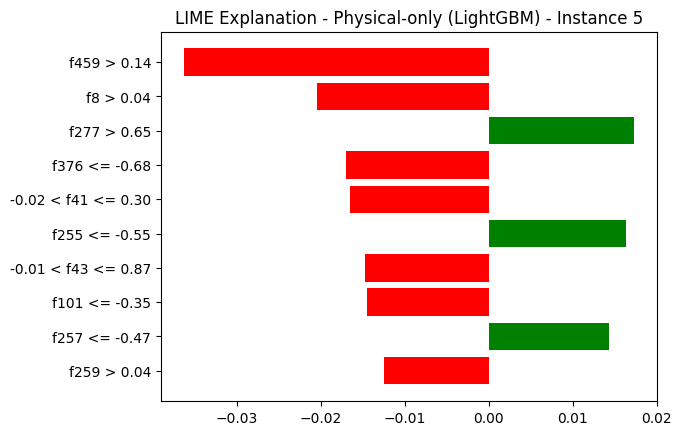

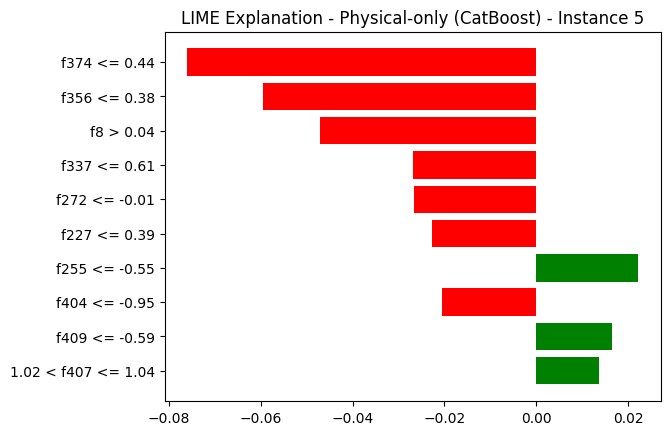

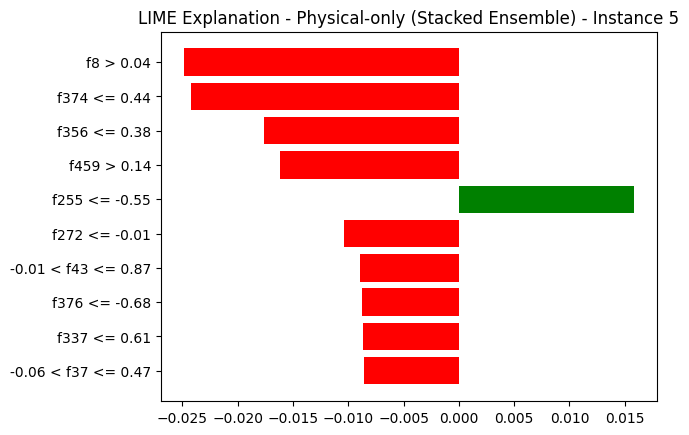

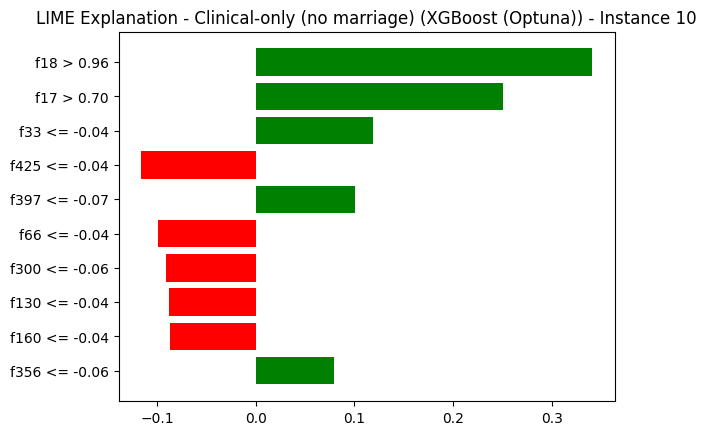

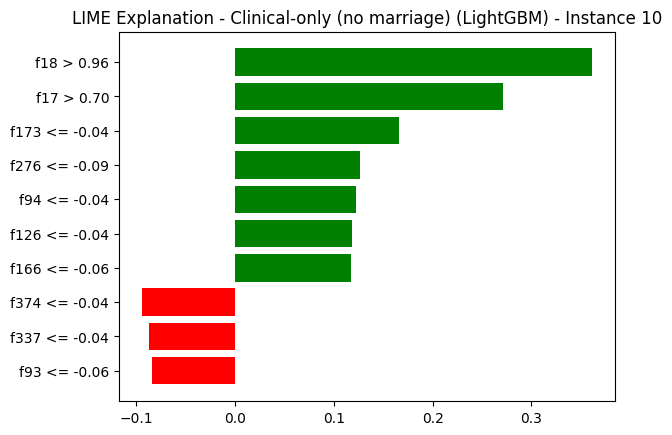

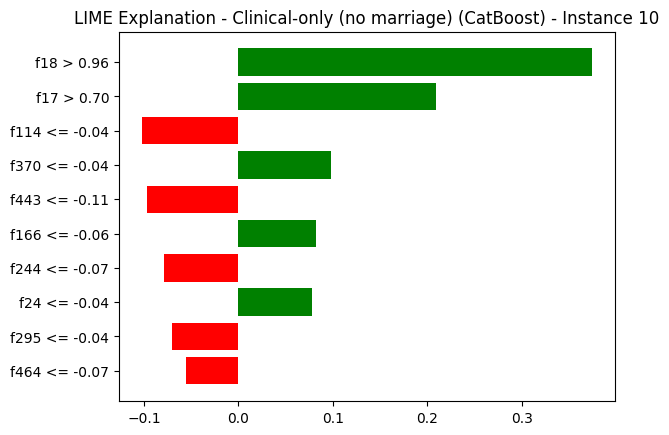

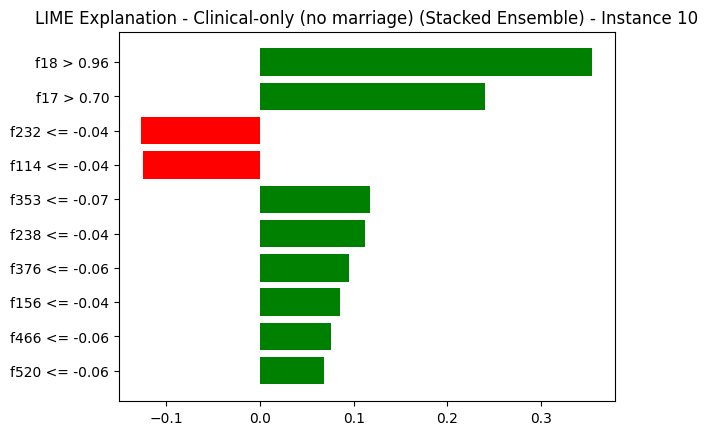

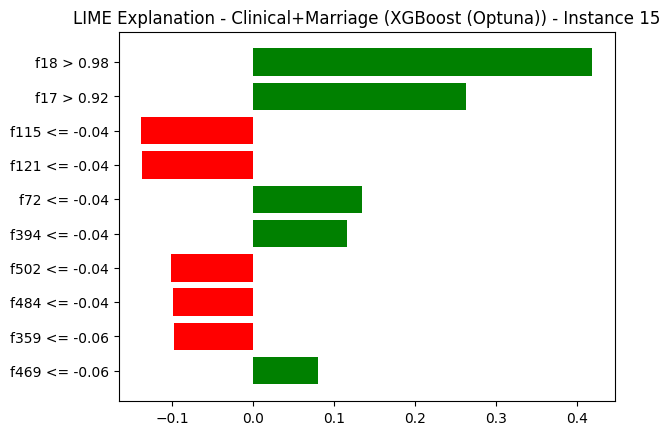

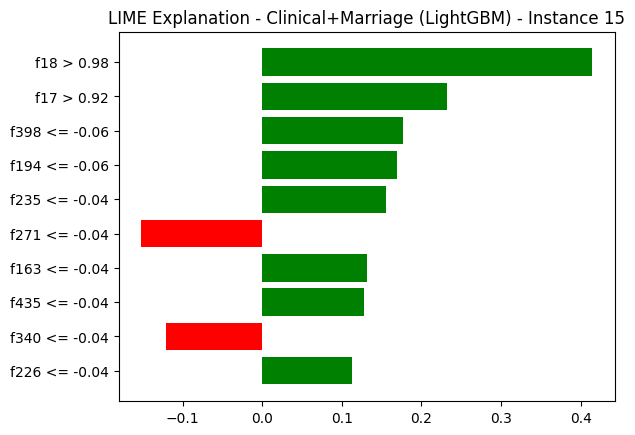

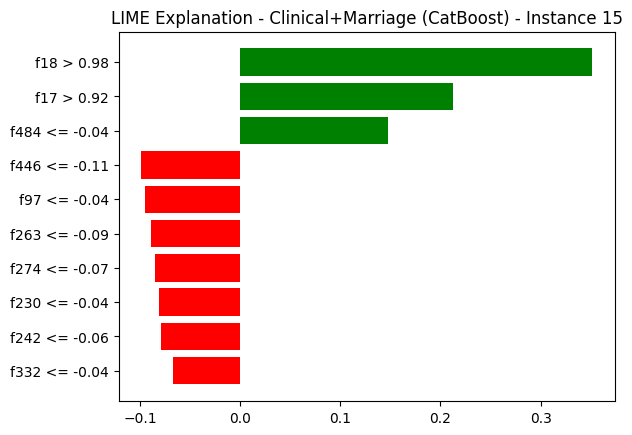

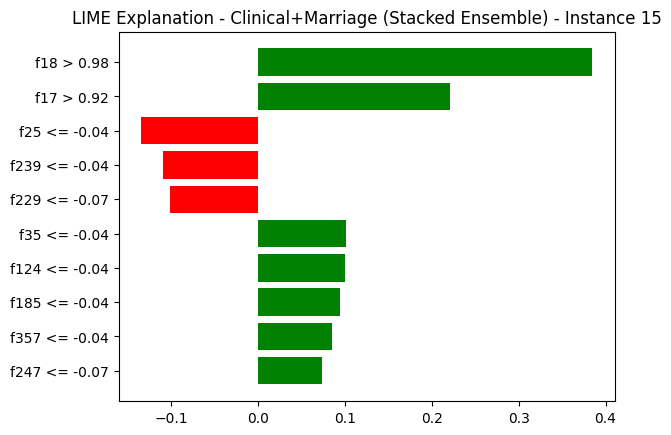

In [41]:
from lime import lime_tabular

def lime_explain_all(models_dict, X_train, X_test, dataset_label, feature_names, class_names=["No PCOS","PCOS"], instance_idx=0):
    """
    Generate LIME explanations for all models in a dataset.
    """
    explainer = lime_tabular.LimeTabularExplainer(
        training_data=np.array(X_train),
        feature_names=feature_names,
        class_names=class_names,
        mode="classification"
    )
    
    for name, model in models_dict.items():
        exp = explainer.explain_instance(X_test[instance_idx], model.predict_proba, num_features=10)
        exp.as_pyplot_figure()
        plt.title(f"LIME Explanation - {dataset_label} ({name}) - Instance {instance_idx}")
        plt.show()
lime_explain_all(models_phys, X_phys_test, X_phys_test, 
                 "Physical-only", [f"f{i}" for i in range(X_phys_test.shape[1])], instance_idx=5)
lime_explain_all(models_clin, X_clin_test, X_clin_test, 
                 "Clinical-only (no marriage)", [f"f{i}" for i in range(X_clin_test.shape[1])], instance_idx=10)
lime_explain_all(models_clin_m, X_clin_m_test, X_clin_m_test, 
                 "Clinical+Marriage", [f"f{i}" for i in range(X_clin_m_test.shape[1])], instance_idx=15)

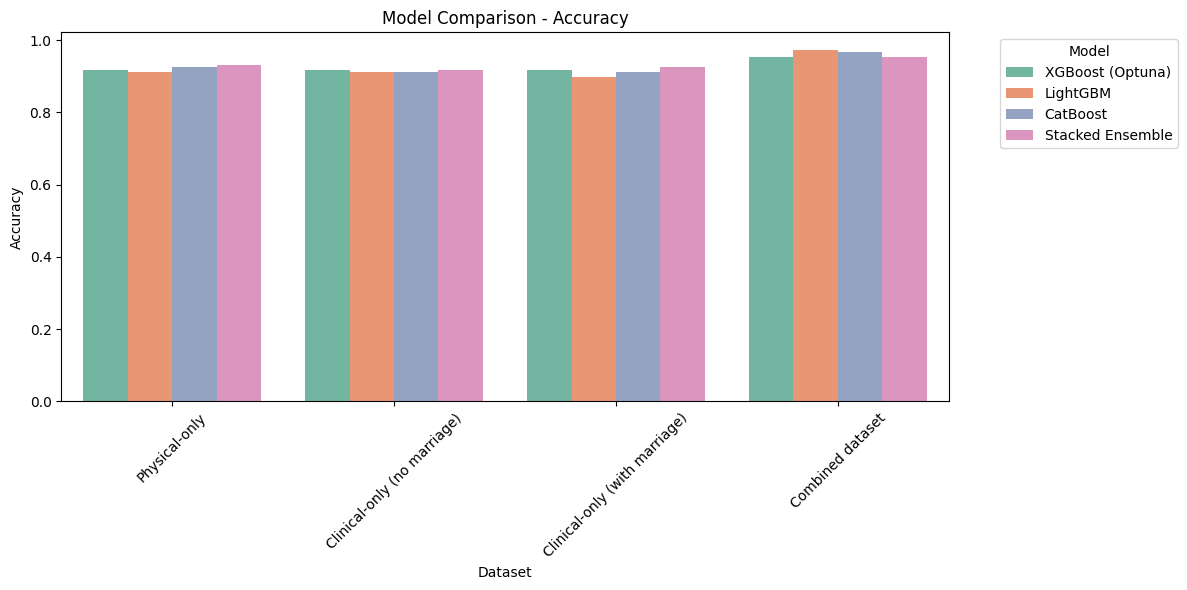

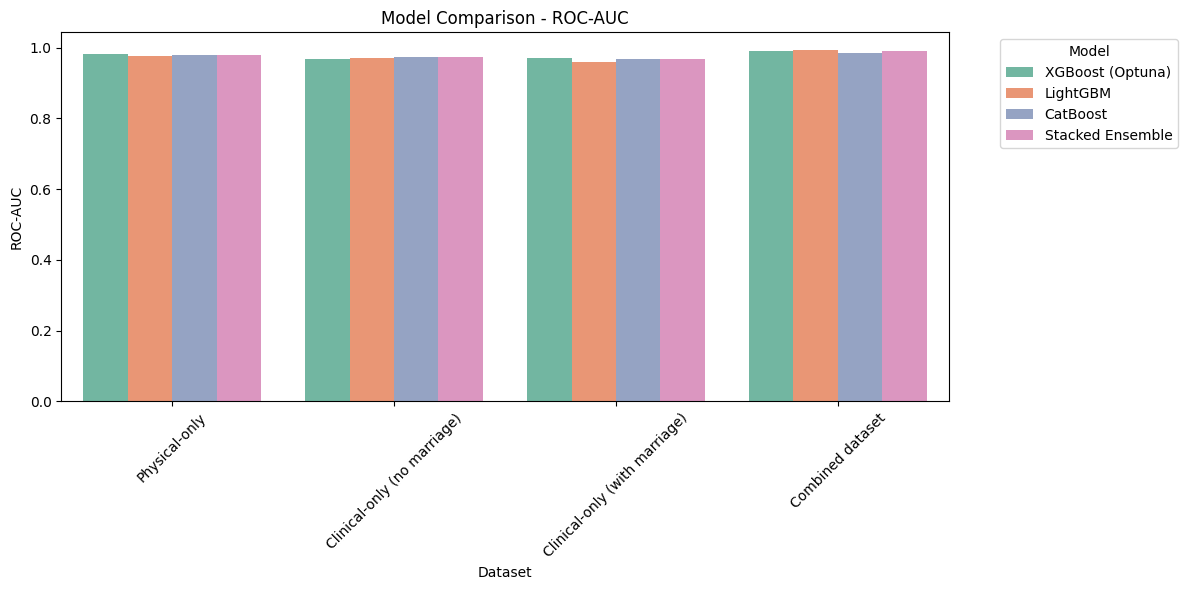

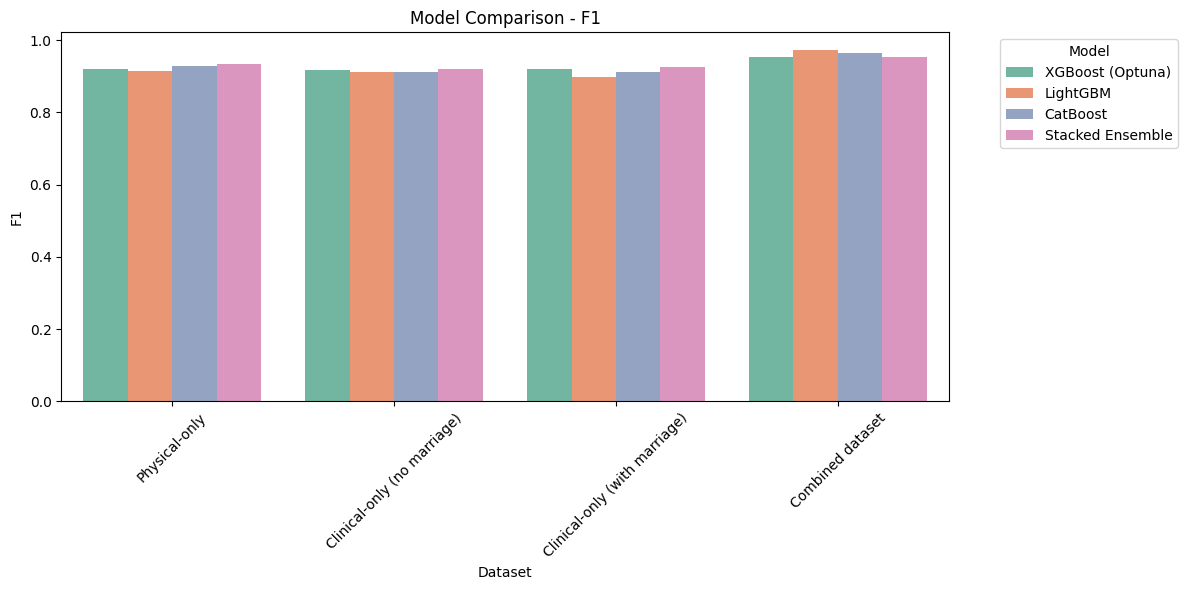

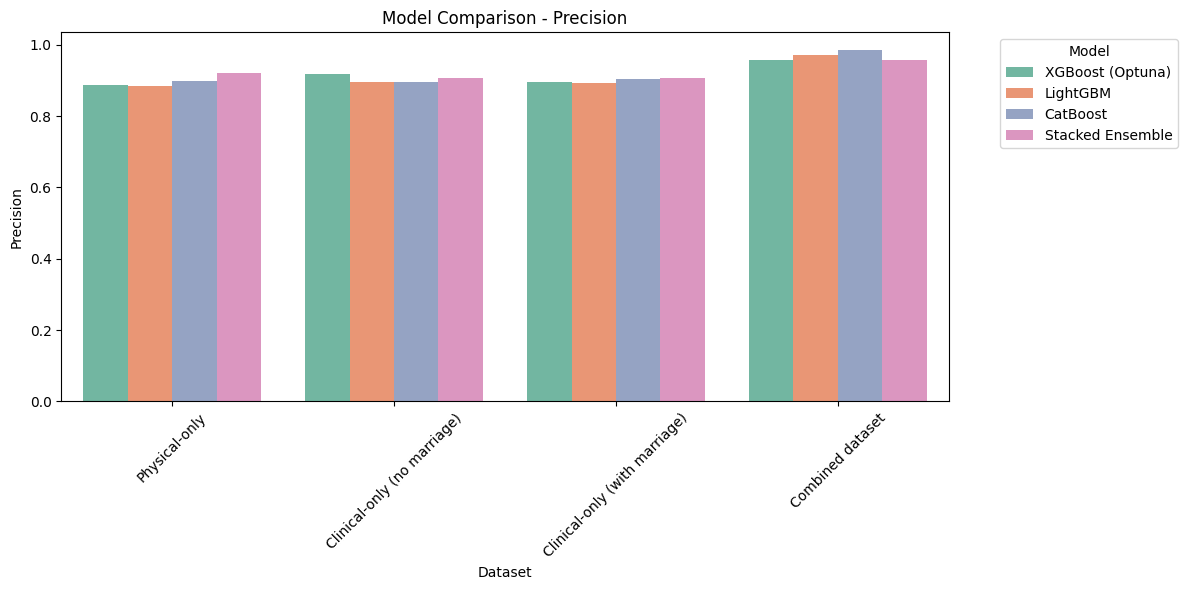

In [43]:
metrics = ["Accuracy", "ROC-AUC", "F1", "Precision"]

for metric in metrics:
    plt.figure(figsize=(12,6))
    sns.barplot(data=final_results, x="Dataset", y=metric, hue="Model", palette="Set2")
    plt.title(f"Model Comparison - {metric}")
    plt.xticks(rotation=45)
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/model_comparison_{metric.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()


In [46]:
import joblib, shutil, os

def save_model(model, name):
    # Ensure output directory exists
    os.makedirs("/kaggle/output", exist_ok=True)
    
    path_working = f"/kaggle/working/{name}.pkl"
    path_output = f"/kaggle/output/{name}.pkl"
    
    joblib.dump(model, path_working)
    shutil.copy(path_working, path_output)
    print(f"Saved {name} to Kaggle output.")

save_model(models_phys["CatBoost"], "pcos_catboost_phys")
save_model(models_clin["Stacked Ensemble"], "pcos_ensemble_clin")
save_model(models_clin_m["Stacked Ensemble"], "pcos_ensemble_clin_m")
save_model(models_comb["LightGBM"], "pcos_lightgbm_comb")



Saved pcos_catboost_phys to Kaggle output.
Saved pcos_ensemble_clin to Kaggle output.
Saved pcos_ensemble_clin_m to Kaggle output.
Saved pcos_lightgbm_comb to Kaggle output.
